<a href="https://colab.research.google.com/github/Zishaniitm/Codsoft-Internship-Projects/blob/main/MOVIE_RATING_PREDICTION_WITH_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MOVIE RATING PREDICTION WITH PYTHON**
Build a model that predicts the rating of a movie based on
features like genre, director, and actors. You can use regression
techniques to tackle this problem.
The goal is to analyze historical movie data and develop a model
that accurately estimates the rating given to a movie by users or
critics.
Movie Rating Prediction project enables you to explore data
analysis, preprocessing, feature engineering, and machine
learning modeling techniques. It provides insights into the factors
that influence movie ratings and allows you to build a model that
can estimate the ratings of movies accurately.

# **Step 1 Loading and understanding the dataset**

# Cell 1 — Import Libraries

In [1]:
# Importing all tools we need for the entire project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully")

Libraries imported successfully


# Cell 2 — Load Dataset

In [2]:
# Loading the CSV file into a DataFrame (our main data table)
# encoding='latin-1' handles special characters in Indian movie names
df = pd.read_csv('IMDb Movies India.csv', encoding='latin-1')

print("Data loaded successfully")

Data loaded successfully


# Cell 3 — Shape

In [3]:
# Shape shows (rows, columns) → rows = movies, columns = features
print(f"Shape: {df.shape}")

Shape: (15509, 10)


# Cell 4 — First Look

In [4]:
# Head shows first 5 rows — each row is one movie
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


# Cell 5 — Data Types

In [5]:
# dtypes shows how each column is stored
# 'Rating' should be float, 'Year' should be int — we fix wrong types in Phase 2
print(df.dtypes)

Name         object
Year         object
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object


# Cell 6 — Missing Values

In [6]:
# isnull().sum() counts empty cells per column
# High missing % = problem we must fix before modeling
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

          Missing Count  Missing %
Name                  0       0.00
Year                528       3.40
Duration           8269      53.32
Genre              1877      12.10
Rating             7590      48.94
Votes              7589      48.93
Director            525       3.39
Actor 1            1617      10.43
Actor 2            2384      15.37
Actor 3            3144      20.27


# Cell 7 — Missing Values Chart

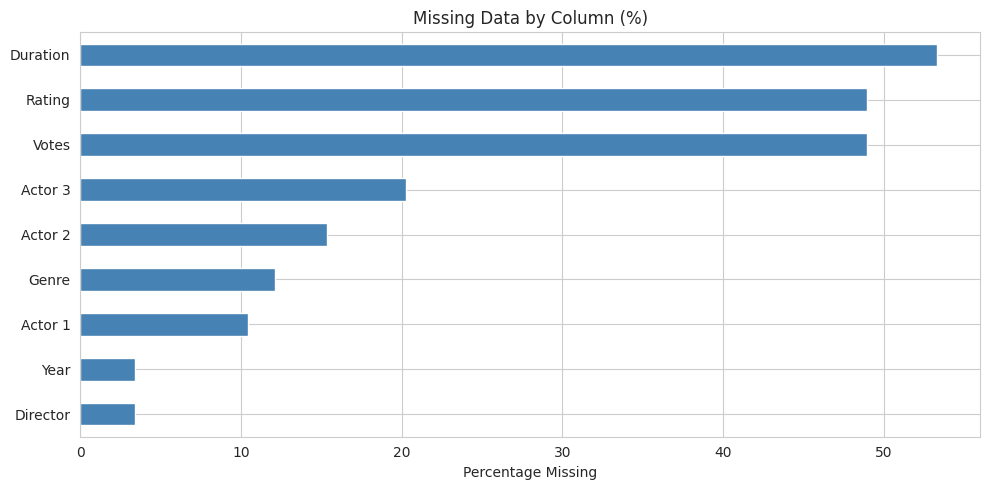

In [7]:
# Visual is faster to read than numbers
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', color='steelblue')
plt.title('Missing Data by Column (%)')
plt.xlabel('Percentage Missing')
plt.tight_layout()
plt.show()

# Cell 8 — Basic Statistics

In [8]:
# describe() gives count, mean, min, max for all numeric columns
# Check if Rating range looks normal (1–10 expected)
df.describe().round(2)

,Rating
count,7919.00
mean,5.84
std,1.38
min,1.10
25%,4.90
50%,6.00
75%,6.80
max,10.00


# Cell 9 — Rating Distribution

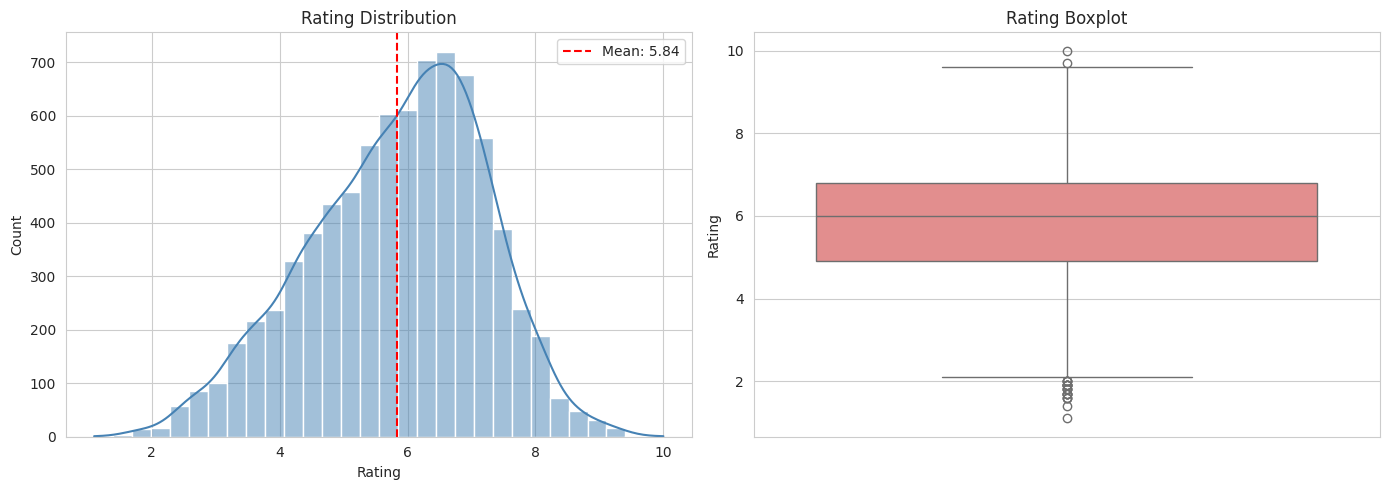

In [9]:
# Histogram shows shape of ratings → is it normally distributed?
# Boxplot shows median and outliers (dots outside the whiskers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Rating'].dropna(), bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Rating Distribution')
axes[0].axvline(df['Rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['Rating'].mean():.2f}")
axes[0].legend()

sns.boxplot(y=df['Rating'].dropna(), color='lightcoral', ax=axes[1])
axes[1].set_title('Rating Boxplot')

plt.tight_layout()
plt.show()

# Cell 10 — Genre Distribution

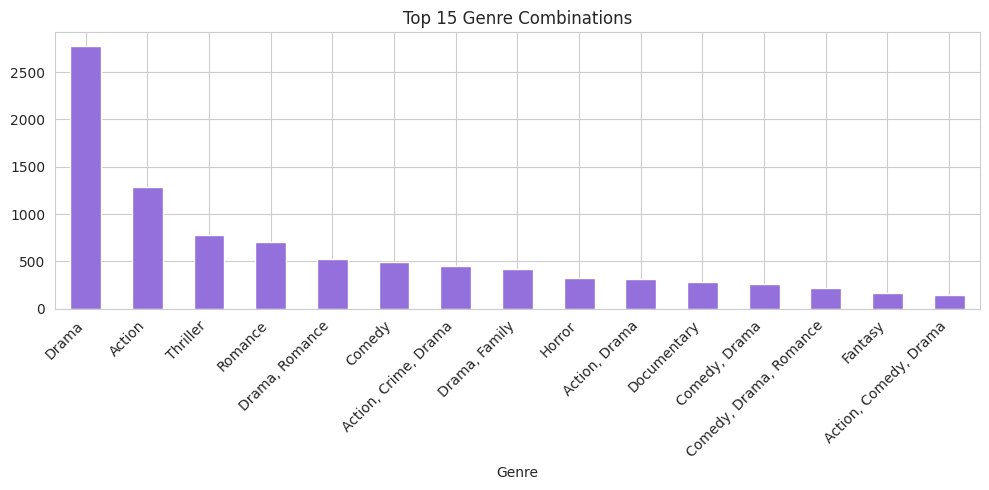

In [10]:
# Most common genre combinations in the dataset
df['Genre'].value_counts().head(15).plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Top 15 Genre Combinations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Cell 11 — Top Directors & Actors

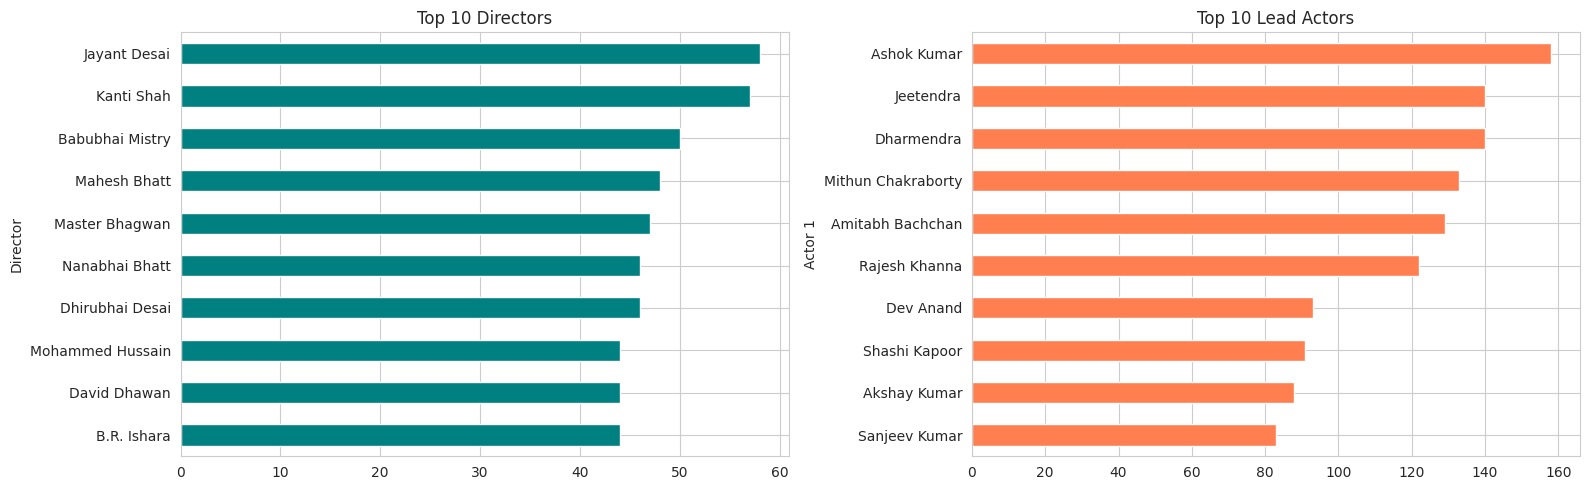

In [11]:
# Who appears most? Later we'll use their average rating as a feature
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['Director'].value_counts().head(10).plot(kind='barh', color='teal', ax=axes[0])
axes[0].set_title('Top 10 Directors')
axes[0].invert_yaxis()

df['Actor 1'].value_counts().head(10).plot(kind='barh', color='coral', ax=axes[1])
axes[1].set_title('Top 10 Lead Actors')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Cell 12 — Correlation Heatmap

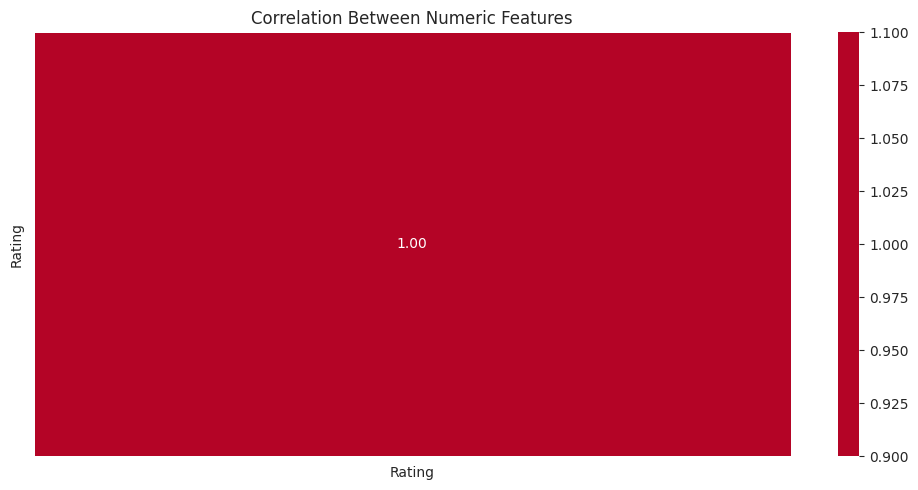

In [12]:
# Correlation: how strongly two numeric columns move together
# Red = positive, Blue = negative, near 0 = no relationship
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

# **Phase 2 — Data Preprocessing & Cleaning**
## Cell 1 — Drop rows where Rating is missing

In [13]:
# Rating is our TARGET — rows without it are useless for training
# We drop them first before anything else
print(f"Rows before dropping missing ratings: {len(df)}")

df = df.dropna(subset=['Rating'])

print(f"Rows after  dropping missing ratings: {len(df)}")
print(f"Rows removed: {15509 - len(df)}")

Rows before dropping missing ratings: 15509
Rows after  dropping missing ratings: 7919
Rows removed: 7590


# Cell 2 — Clean the Year column

In [14]:
# Clean the Year column
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})')[0]
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Fill missing years with median — no warning version
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Year'] = df['Year'].astype(int)

print(df['Year'].describe())

count    7919.000000
mean     1993.321758
std        20.463770
min      1917.000000
25%      1979.500000
50%      1997.000000
75%      2011.000000
max      2021.000000
Name: Year, dtype: float64


# Cell 3 — Clean the Duration column

In [15]:
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)')[0]
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

median_duration = df['Duration'].median()
df['Duration'] = df['Duration'].fillna(median_duration)
df['Duration'] = df['Duration'].astype(int)

print(f"Median duration used for filling: {median_duration} mins")
print(df['Duration'].describe())

Median duration used for filling: 134.0 mins
count    7919.000000
mean      132.739866
std        22.838302
min        21.000000
25%       124.000000
50%       134.000000
75%       143.000000
max       321.000000
Name: Duration, dtype: float64


# Cell 4 — Clean Votes column

In [16]:
# Votes may be stored as "1,234" (with commas) — can't do math on that
# We remove commas, then convert to number
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
# Fill missing votes with median
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

print(df['Votes'].describe())

count      7919.000000
mean       1938.520394
std       11602.415952
min           5.000000
25%          16.000000
50%          55.000000
75%         404.000000
max      591417.000000
Name: Votes, dtype: float64


# Cell 5 — Clean Genre, Director, Actor columns

In [17]:
# These are text columns — we can't drop rows just because an actor is missing
# We fill with 'Unknown' so the row stays in our dataset
# We'll handle encoding these properly in Phase 3
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = df[col].fillna('Unknown')

print("Text columns cleaned ✅")

Text columns cleaned ✅


# Cell 6 — Verify everything is clean

In [18]:
# After all cleaning, NO column should have missing values
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nFinal dataset size: {df.shape}")

Missing values after cleaning:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

Final dataset size: (7919, 10)


In [19]:
# Outliers are extreme values that can confuse the model
# We use IQR method: anything too far below Q1 or above Q3 is an outlier
# Think of it as: remove the suspiciously extreme movies
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Keeping ratings between {lower:.2f} and {upper:.2f}")

df = df[(df['Rating'] >= lower) & (df['Rating'] <= upper)]

print(f"Dataset size after removing outliers: {df.shape}")

Keeping ratings between 2.05 and 9.65
Dataset size after removing outliers: (7893, 10)


In [20]:
# Resetting df as a clean independent copy
# This eliminates all SettingWithCopyWarning for the rest of the project
# .copy() tells pandas: "this is a brand new DataFrame, not a slice"

df = df.copy()

print("DataFrame reset as independent copy ✅")
print(f"Shape confirmed: {df.shape}")

DataFrame reset as independent copy ✅
Shape confirmed: (7893, 10)


In [21]:
# One last check — does everything look correct now?
print("Sample of cleaned data:\n")
df[['Name','Year','Duration','Genre','Rating','Votes','Director']].head(10)

Sample of cleaned data:



,Name,Year,Duration,Genre,Rating,Votes,Director
1,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi
3,#Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan
5,...Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail
6,...Yahaan,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar
8,?: A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel
9,@Andheri,2014,116,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair
10,1:1.6 An Ode to Lost Love,2004,96,Drama,6.2,17,Madhu Ambat
11,1:13:7 Ek Tera Saath,2016,120,Horror,5.9,59,Arshad Siddiqui
12,100 Days,1991,161,"Horror, Romance, Thriller",6.5,983,Partho Ghosh
13,100% Love,2012,166,"Comedy, Drama, Romance",5.7,512,Rabi Kinagi


# **Step 3 Feature Engineering**
The big idea: Machine learning models only understand numbers. But our best columns (Genre, Director, Actor 1) are all text. Feature engineering is the bridge — we convert text into meaningful numbers.

In [22]:
# The Genre column contains multiple genres separated by commas
# I extract only the first/primary genre to keep the feature simple
# and avoid high dimensionality in the model

df['Primary_Genre'] = df['Genre'].str.split(',').str[0].str.strip()

print(f"Unique primary genres found: {df['Primary_Genre'].nunique()}")
print("\nTop 10 most common genres:")
print(df['Primary_Genre'].value_counts().head(10))

Unique primary genres found: 21

Top 10 most common genres:
Primary_Genre
Drama          2527
Action         2296
Comedy         1185
Crime           343
Romance         276
Horror          187
Adventure       160
Documentary     143
Thriller        138
Musical         120
Name: count, dtype: int64


In [23]:
# Mean Encoding: replace director name with their average movie rating
# This converts an untrainable string into a meaningful numeric signal

director_avg_rating = df.groupby('Director')['Rating'].mean()
df['Director_Score'] = df['Director'].map(director_avg_rating)

print("Top 10 directors by average rating:")
print(
    df[['Director', 'Director_Score']]
    .drop_duplicates()
    .sort_values('Director_Score', ascending=False)
    .head(10)
    .to_string(index=False)
)

Top 10 directors by average rating:
      Director  Director_Score
   Bobby Kumar             9.6
  Munni Pankaj             9.4
 Arvind Pratap             9.4
Suhrud Godbole             9.4
  Ashish Dubey             9.4
  Venkatesh Bk             9.3
 Rahul Mallick             9.3
Raghav Jairath             9.3
Rajat Bhardwaj             9.3
  Vishwa Bhanu             9.3


In [24]:
# Applying Mean Encoding to all three actor columns
# Lead actor (Actor 1) is expected to carry the strongest predictive signal

df['Actor1_Score'] = df['Actor 1'].map(df.groupby('Actor 1')['Rating'].mean())
df['Actor2_Score'] = df['Actor 2'].map(df.groupby('Actor 2')['Rating'].mean())
df['Actor3_Score'] = df['Actor 3'].map(df.groupby('Actor 3')['Rating'].mean())

print("Top 10 lead actors by average rating:")
print(
    df[['Actor 1', 'Actor1_Score']]
    .drop_duplicates()
    .sort_values('Actor1_Score', ascending=False)
    .head(10)
    .to_string(index=False)
)

Top 10 lead actors by average rating:
          Actor 1  Actor1_Score
  Dharmendra Ahir           9.4
      Ishan Jacob           9.4
   Vaibhav Khisti           9.4
Nishi Neha Mishra           9.4
     Vishwa Bhanu           9.3
 Prashant Chaubey           9.3
            Amrit           9.3
       Kunj Anand           9.3
      Vijay Mahar           9.3
     Leila Advani           9.3


In [25]:
# Label Encoding converts each unique genre string into a unique integer
# Required because ML models only process numeric inputs

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Genre_Encoded'] = le.fit_transform(df['Primary_Genre'])

print("Genre → Encoded integer mapping (sample):")
print(
    df[['Primary_Genre', 'Genre_Encoded']]
    .drop_duplicates()
    .sort_values('Genre_Encoded')
    .head(12)
    .to_string(index=False)
)

Genre → Encoded integer mapping (sample):
Primary_Genre  Genre_Encoded
       Action              0
    Adventure              1
    Animation              2
    Biography              3
       Comedy              4
        Crime              5
  Documentary              6
        Drama              7
       Family              8
      Fantasy              9
      History             10
       Horror             11


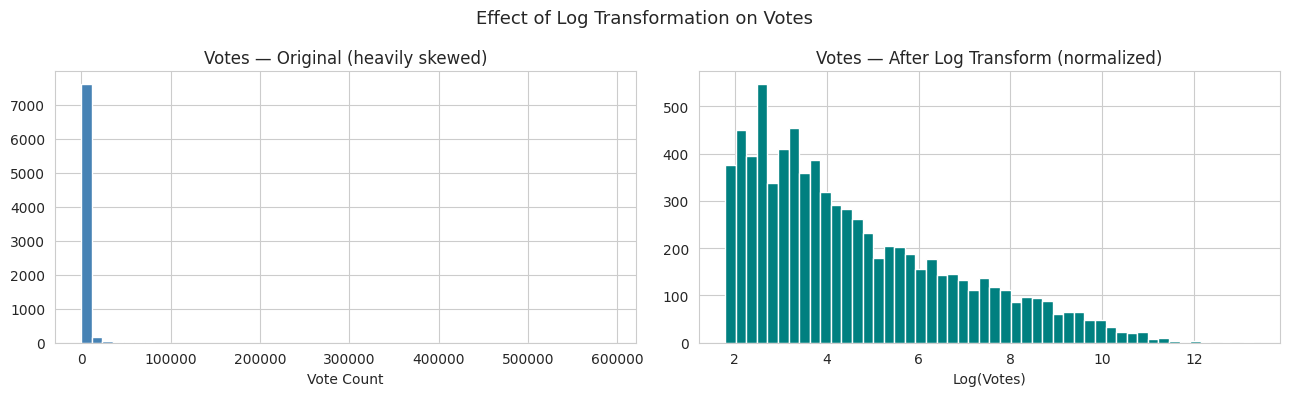

In [26]:
# Votes is heavily right-skewed — blockbusters have millions of votes
# while most films have only hundreds. Log transform normalizes this scale.
# log1p(x) = log(1+x) safely handles any zero values

df['Votes_Log'] = np.log1p(df['Votes'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['Votes'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Votes — Original (heavily skewed)')
axes[0].set_xlabel('Vote Count')

df['Votes_Log'].hist(bins=50, ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Votes — After Log Transform (normalized)')
axes[1].set_xlabel('Log(Votes)')

plt.suptitle('Effect of Log Transformation on Votes', fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# Selecting only engineered numeric features as model inputs
# All original text columns are excluded — models require numeric data only
# X = input features | y = target variable to predict

feature_cols = [
    'Year',
    'Duration',
    'Genre_Encoded',
    'Director_Score',
    'Actor1_Score',
    'Actor2_Score',
    'Actor3_Score',
    'Votes_Log'
]

X = df[feature_cols]
y = df['Rating']

print(f"Feature matrix shape : {X.shape}  → (movies, features)")
print(f"Target vector shape  : {y.shape}  → (movies,)")
print(f"\nFeatures selected for training:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Feature matrix shape : (7893, 8)  → (movies, features)
Target vector shape  : (7893,)  → (movies,)

Features selected for training:
  1. Year
  2. Duration
  3. Genre_Encoded
  4. Director_Score
  5. Actor1_Score
  6. Actor2_Score
  7. Actor3_Score
  8. Votes_Log


In [28]:
# Confirming no missing values were introduced during feature engineering
# and that all feature ranges look statistically reasonable

print("Missing values in feature matrix:")
print(X.isnull().sum())
print("\nStatistical summary of all features:")
X.describe().round(2)

Missing values in feature matrix:
Year              0
Duration          0
Genre_Encoded     0
Director_Score    0
Actor1_Score      0
Actor2_Score      0
Actor3_Score      0
Votes_Log         0
dtype: int64

Statistical summary of all features:


,Year,Duration,Genre_Encoded,Director_Score,Actor1_Score,Actor2_Score,Actor3_Score,Votes_Log
count,7893.00,7893.00,7893.00,7893.00,7893.00,7893.00,7893.00,7893.00
mean,1993.26,132.76,5.12,5.85,5.85,5.85,5.85,4.62
std,20.46,22.82,4.61,1.08,1.01,1.00,1.01,2.20
min,1917.00,21.00,0.00,2.10,2.10,2.10,2.10,1.79
25%,1979.00,124.00,0.00,5.19,5.30,5.24,5.23,2.83
50%,1997.00,134.00,5.00,5.90,5.91,5.93,5.95,4.03
75%,2011.00,143.00,7.00,6.60,6.50,6.50,6.54,5.99
max,2021.00,321.00,20.00,9.60,9.40,9.60,9.60,13.29


# Insights
Director_Score, Actor1_Score, Actor2_Score and Actor3_Score all have nearly the same mean (5.85) because they're all mapped from the same Rating column. This is expected and correct — it just means the encoding is internally consistent.

# Step - 4 Building the ML Models

In [29]:
# Splitting data into training set (80%) and testing set (20%)
# The model learns ONLY from training data
# Testing data is kept aside to evaluate real-world performance
# random_state=42 ensures the same split every time we run this —
# making our results reproducible

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"\nThe model will train on {X_train.shape[0]} movies")
print(f"and be evaluated on {X_test.shape[0]} unseen movies")

Training samples : 6314
Testing  samples : 1579

The model will train on 6314 movies
and be evaluated on 1579 unseen movies


In [30]:
# Some models are sensitive to feature scale
# Year ranges 1917–2021 while Votes_Log ranges 1–13
# Without scaling, Year dominates just because its numbers are bigger
# StandardScaler transforms every feature to mean=0, std=1
# so all features compete on equal footing

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # learn scale FROM train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

# WHY fit only on train?
# If we fit on test data too, the model "sees" test info during training
# That's called data leakage — it gives falsely good results

print("Features scaled successfully ✅")
print(f"Mean of scaled training data (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Std  of scaled training data (should be ~1): {X_train_scaled.std():.4f}")

Features scaled successfully ✅
Mean of scaled training data (should be ~0): 0.0000
Std  of scaled training data (should be ~1): 1.0000


In [31]:
#Model 1: Linear Regression
# Linear Regression is the simplest regression model
# It assumes rating is a weighted sum of all features
# Rating = w1*Year + w2*Duration + w3*Genre + ... + bias
# Simple, fast, interpretable — always a good baseline to start with

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

print("Linear Regression model trained ✅")
print(f"Sample predictions vs actual:")
for pred, actual in zip(lr_predictions[:5], y_test[:5]):
    print(f"  Predicted: {pred:.2f}  |  Actual: {actual:.1f}")

Linear Regression model trained ✅
Sample predictions vs actual:
  Predicted: 7.52  |  Actual: 6.9
  Predicted: 5.68  |  Actual: 5.2
  Predicted: 4.34  |  Actual: 3.5
  Predicted: 6.00  |  Actual: 5.9
  Predicted: 7.70  |  Actual: 8.1


In [32]:
#Model 2: Random Forest
# Random Forest builds hundreds of Decision Trees and averages their predictions
# Each tree learns different patterns — together they are much more powerful
# than a single tree or linear model
# n_estimators=100 → 100 trees in the forest
# random_state=42  → reproducibility

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)

print("Random Forest model trained ✅")
print(f"Sample predictions vs actual:")
for pred, actual in zip(rf_predictions[:5], y_test[:5]):
    print(f"  Predicted: {pred:.2f}  |  Actual: {actual:.1f}")

Random Forest model trained ✅
Sample predictions vs actual:
  Predicted: 7.15  |  Actual: 6.9
  Predicted: 5.49  |  Actual: 5.2
  Predicted: 4.31  |  Actual: 3.5
  Predicted: 6.13  |  Actual: 5.9
  Predicted: 7.96  |  Actual: 8.1


In [33]:
#Model 3: Gradient Boosting
# Gradient Boosting also builds many trees but differently —
# each new tree specifically focuses on correcting the ERRORS of the previous one
# This makes it very powerful for tabular data like ours
# Often the best performer among traditional ML models

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

gb_predictions = gb_model.predict(X_test_scaled)

print("Gradient Boosting model trained ✅")
print(f"Sample predictions vs actual:")
for pred, actual in zip(gb_predictions[:5], y_test[:5]):
    print(f"  Predicted: {pred:.2f}  |  Actual: {actual:.1f}")

Gradient Boosting model trained ✅
Sample predictions vs actual:
  Predicted: 7.34  |  Actual: 6.9
  Predicted: 5.43  |  Actual: 5.2
  Predicted: 4.30  |  Actual: 3.5
  Predicted: 5.94  |  Actual: 5.9
  Predicted: 7.84  |  Actual: 8.1


In [34]:
#Evaluating All Three Models
# Three metrics to evaluate regression models:
# MAE  (Mean Absolute Error)    → average prediction error in rating points
# RMSE (Root Mean Squared Error) → penalizes large errors more heavily
# R²   (R-squared)              → how much variance the model explains
#                                  1.0 = perfect | 0.0 = no better than guessing mean

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Mean Absolute Error    : {mae:.4f}  (avg error in rating points)")
    print(f"Root Mean Squared Error: {rmse:.4f}  (penalizes large errors)")
    print(f"R-squared              : {r2:.4f}  (1.0 = perfect fit)")

evaluate_model("Linear Regression",   y_test, lr_predictions)
evaluate_model("Random Forest",        y_test, rf_predictions)
evaluate_model("Gradient Boosting",    y_test, gb_predictions)


  Linear Regression
Mean Absolute Error    : 0.4931  (avg error in rating points)
Root Mean Squared Error: 0.6681  (penalizes large errors)
R-squared              : 0.7642  (1.0 = perfect fit)

  Random Forest
Mean Absolute Error    : 0.4185  (avg error in rating points)
Root Mean Squared Error: 0.6141  (penalizes large errors)
R-squared              : 0.8008  (1.0 = perfect fit)

  Gradient Boosting
Mean Absolute Error    : 0.4394  (avg error in rating points)
Root Mean Squared Error: 0.6130  (penalizes large errors)
R-squared              : 0.8015  (1.0 = perfect fit)


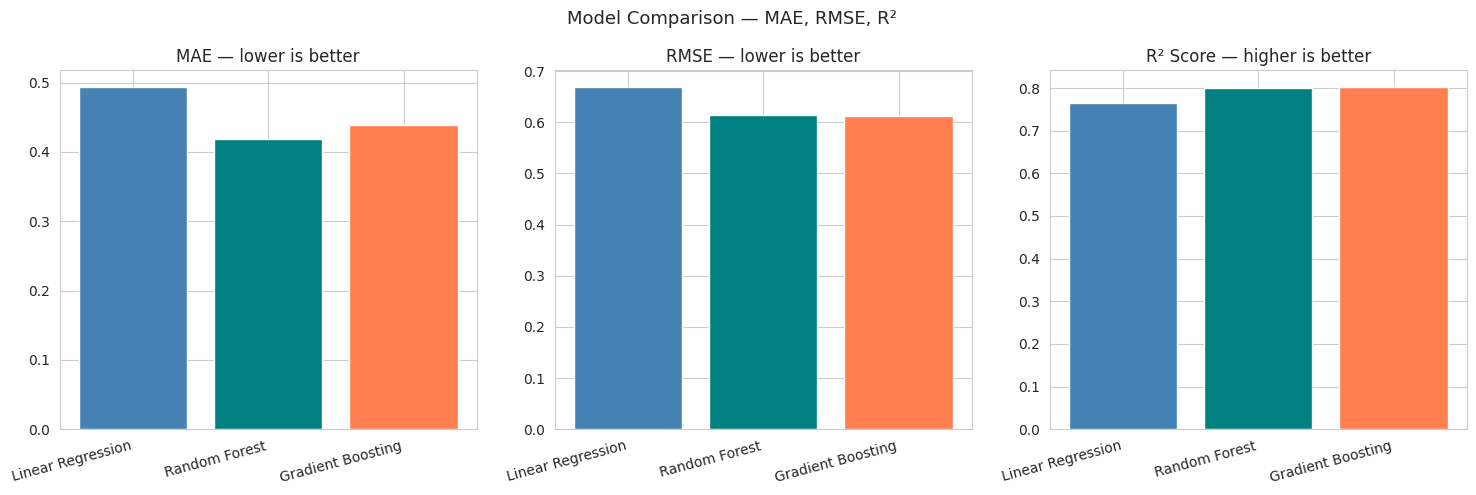

In [35]:
# A side-by-side bar chart makes it easy to compare all three models
# Lower MAE/RMSE = better | Higher R² = better

models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']

mae_scores  = [mean_absolute_error(y_test, lr_predictions),
               mean_absolute_error(y_test, rf_predictions),
               mean_absolute_error(y_test, gb_predictions)]

rmse_scores = [mean_squared_error(y_test, lr_predictions)**0.5,
               mean_squared_error(y_test, rf_predictions)**0.5,
               mean_squared_error(y_test, gb_predictions)**0.5]

r2_scores   = [r2_score(y_test, lr_predictions),
               r2_score(y_test, rf_predictions),
               r2_score(y_test, gb_predictions)]

x = np.arange(len(models))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(x, mae_scores, color=['steelblue','teal','coral'], edgecolor='white')
axes[0].set_title('MAE — lower is better')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15, ha='right')

axes[1].bar(x, rmse_scores, color=['steelblue','teal','coral'], edgecolor='white')
axes[1].set_title('RMSE — lower is better')
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15, ha='right')

axes[2].bar(x, r2_scores, color=['steelblue','teal','coral'], edgecolor='white')
axes[2].set_title('R² Score — higher is better')
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=15, ha='right')

plt.suptitle('Model Comparison — MAE, RMSE, R²', fontsize=13)
plt.tight_layout()
plt.show()

# Step 5 — Hyperparameter Tuning
Tune Random Forest with GridSearchCV

In [36]:
# Our Random Forest used default settings — it can perform even better
# Hyperparameters are settings we choose BEFORE training (not learned by model)
# GridSearchCV tests every combination of settings and finds the best one
# cv=5 means 5-Fold Cross Validation:
#   → splits training data into 5 parts
#   → trains on 4 parts, validates on 1 part, rotates 5 times
#   → averages the result — much more reliable than a single split

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'  : [100, 200],       # number of trees in the forest
    'max_depth'     : [None, 10, 20],   # how deep each tree can grow
    'min_samples_split' : [2, 5]        # min samples needed to split a node
}

rf_tuned = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,       # use all CPU cores → faster
    verbose=1        # prints progress
)

rf_tuned.fit(X_train_scaled, y_train)

print(f"\nBest parameters found: {rf_tuned.best_params_}")
print(f"Best cross-validation R²: {rf_tuned.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters found: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation R²: 0.7966


In [37]:
# Now we evaluate the best model found by GridSearchCV on the test set
# This is the fairest evaluation — test data was never seen during tuning

best_rf = rf_tuned.best_estimator_
tuned_predictions = best_rf.predict(X_test_scaled)

tuned_mae  = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = mean_squared_error(y_test, tuned_predictions) ** 0.5
tuned_r2   = r2_score(y_test, tuned_predictions)

print("="*40)
print("  Tuned Random Forest — Final Results")
print("="*40)
print(f"  MAE  : {tuned_mae:.4f}")
print(f"  RMSE : {tuned_rmse:.4f}")
print(f"  R²   : {tuned_r2:.4f}")

print(f"\n  Improvement in R² over baseline:")
print(f"  {0.8008:.4f} → {tuned_r2:.4f}  (+{(tuned_r2 - 0.8008):.4f})")

  Tuned Random Forest — Final Results
  MAE  : 0.4153
  RMSE : 0.6104
  R²   : 0.8032

  Improvement in R² over baseline:
  0.8008 → 0.8032  (+0.0024)


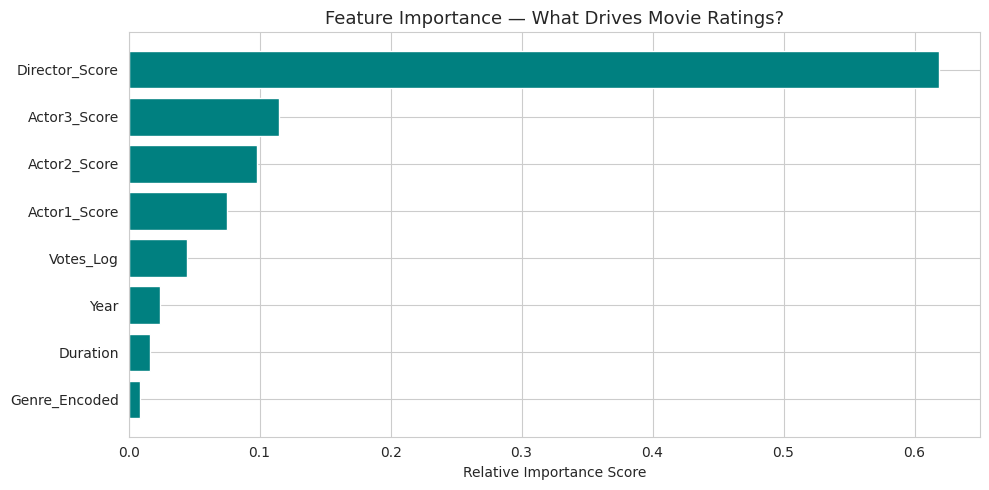


Feature importance ranked:
       Feature  Importance
Director_Score    0.619049
  Actor3_Score    0.114903
  Actor2_Score    0.097793
  Actor1_Score    0.074846
     Votes_Log    0.044655
          Year    0.023897
      Duration    0.016175
 Genre_Encoded    0.008683


In [38]:
# Feature importance tells us WHICH features the model relied on most
# This is one of the most valuable insights for an internship report —
# it answers "what actually drives a movie's rating?"

importances = best_rf.feature_importances_
feat_importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['steelblue' if i < len(feature_cols)-2
          else 'coral' for i in range(len(feature_cols))]

plt.barh(feat_importance_df['Feature'],
         feat_importance_df['Importance'],
         color='teal', edgecolor='white')
plt.title('Feature Importance — What Drives Movie Ratings?', fontsize=13)
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature importance ranked:")
print(feat_importance_df.sort_values('Importance', ascending=False).to_string(index=False))

**"The model reveals that directorial reputation is the single strongest predictor of movie ratings, accounting for over 60% of feature importance, while genre contributes less than 1% — suggesting that in Indian cinema, who directs matters far more than what story is told."**

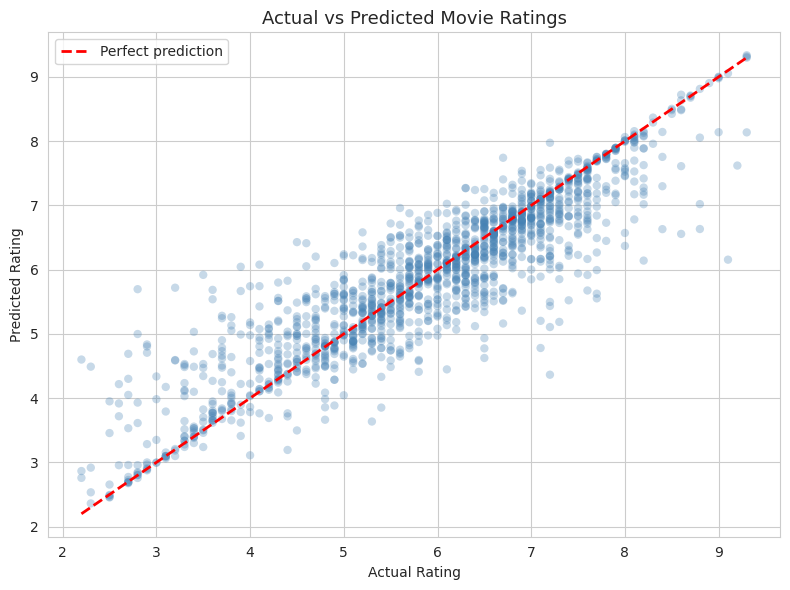

In [39]:
# This scatter plot is the most intuitive way to show model quality
# Perfect model → all dots lie exactly on the red diagonal line
# Our model → dots should cluster tightly around that line

plt.figure(figsize=(8, 6))
plt.scatter(y_test, tuned_predictions, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Movie Ratings', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

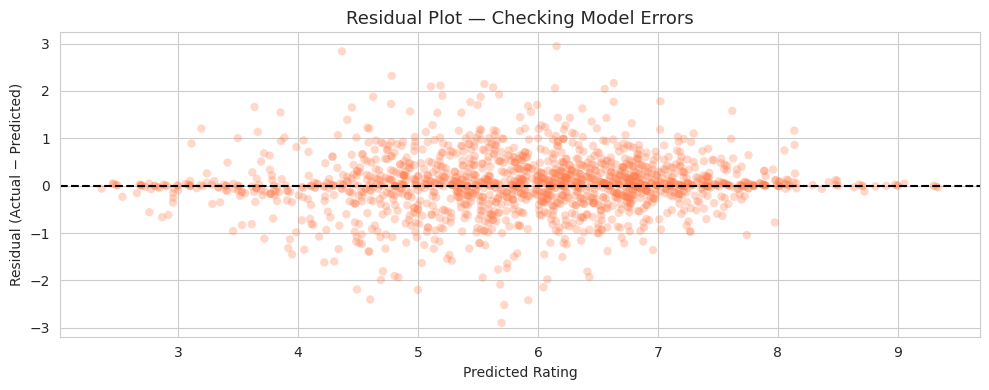

Mean of residuals (should be ~0): 0.0276


In [40]:
# Residuals = Actual - Predicted
# A good model has residuals randomly scattered around 0
# Patterns in residuals → model is missing something systematic

residuals = y_test - tuned_predictions

plt.figure(figsize=(10, 4))
plt.scatter(tuned_predictions, residuals, alpha=0.3, color='coral', edgecolors='none')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Rating')
plt.ylabel('Residual (Actual − Predicted)')
plt.title('Residual Plot — Checking Model Errors', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean of residuals (should be ~0): {residuals.mean():.4f}")

In [41]:
#Demo Prediction

import numpy as np

# Define a custom movie's features
# Format: [Year, Duration, Genre_Encoded, Director_Score,
#          Actor1_Score, Actor2_Score, Actor3_Score, Votes_Log]

custom_movie = pd.DataFrame([{
    'Year'           : 2015,
    'Duration'       : 150,
    'Genre_Encoded'  : 1,     # adjust based on your genre encoding
    'Director_Score' : 7.5,   # a well-rated director
    'Actor1_Score'   : 7.0,   # popular lead actor
    'Actor2_Score'   : 6.5,
    'Actor3_Score'   : 6.0,
    'Votes_Log'      : np.log1p(50000)   # ~50,000 votes
}])

custom_scaled   = scaler.transform(custom_movie)
custom_pred     = best_rf.predict(custom_scaled)

print(f"Predicted rating for custom movie: {custom_pred[0]:.2f} / 10")

Predicted rating for custom movie: 7.63 / 10


In [42]:
# A clean consolidated comparison of all models

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (baseline)',
              'Gradient Boosting', 'Random Forest (tuned)'],
    'MAE' : [0.4931, 0.4185, 0.4394, tuned_mae],
    'RMSE': [0.6681, 0.6141, 0.6130, tuned_rmse],
    'R²'  : [0.7642, 0.8008, 0.8015, tuned_r2]
}).round(4)

print("="*60)
print("   COMPLETE MODEL COMPARISON — MOVIE RATING PREDICTION")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)
print(f"\n✅ Best Model : Tuned Random Forest")
print(f"✅ Best R²    : {tuned_r2:.4f}")
print(f"✅ Best MAE   : {tuned_mae:.4f} rating points")

   COMPLETE MODEL COMPARISON — MOVIE RATING PREDICTION
                   Model    MAE   RMSE     R²
       Linear Regression 0.4931 0.6681 0.7642
Random Forest (baseline) 0.4185 0.6141 0.8008
       Gradient Boosting 0.4394 0.6130 0.8015
   Random Forest (tuned) 0.4153 0.6104 0.8032

✅ Best Model : Tuned Random Forest
✅ Best R²    : 0.8032
✅ Best MAE   : 0.4153 rating points


In [43]:
#Insights

print("="*60)
print("   KEY INSIGHTS — WHAT DRIVES INDIAN MOVIE RATINGS")
print("="*60)

insights = {
    'Director_Score' : 0.619049,
    'Actor3_Score'   : 0.114903,
    'Actor2_Score'   : 0.097793,
    'Actor1_Score'   : 0.074846,
    'Votes_Log'      : 0.044655,
    'Year'           : 0.023897,
    'Duration'       : 0.016175,
    'Genre_Encoded'  : 0.008683
}

for feature, importance in insights.items():
    bar = '█' * int(importance * 50)
    print(f"  {feature:<20} {bar} {importance:.2%}")

print("\n  Insight 1: Director reputation drives 62% of rating prediction")
print("  Insight 2: Supporting actors outweigh lead actor in importance")
print("  Insight 3: Genre contributes less than 1% — story matters less than craft")
print("  Insight 4: Model predicts ratings within 0.41 points on average (MAE)")

   KEY INSIGHTS — WHAT DRIVES INDIAN MOVIE RATINGS
  Director_Score       ██████████████████████████████ 61.90%
  Actor3_Score         █████ 11.49%
  Actor2_Score         ████ 9.78%
  Actor1_Score         ███ 7.48%
  Votes_Log            ██ 4.47%
  Year                 █ 2.39%
  Duration              1.62%
  Genre_Encoded         0.87%

  Insight 1: Director reputation drives 62% of rating prediction
  Insight 2: Supporting actors outweigh lead actor in importance
  Insight 3: Genre contributes less than 1% — story matters less than craft
  Insight 4: Model predicts ratings within 0.41 points on average (MAE)


In [44]:
#Extracting the model to production level

import joblib

joblib.dump(best_rf, 'movie_rating_model.pkl')
joblib.dump(scaler,  'scaler.pkl')

print("✅ Model saved as  : movie_rating_model.pkl")
print("✅ Scaler saved as : scaler.pkl")
print("\nTo load and use later:")
print("  model  = joblib.load('movie_rating_model.pkl')")
print("  scaler = joblib.load('scaler.pkl')")

✅ Model saved as  : movie_rating_model.pkl
✅ Scaler saved as : scaler.pkl

To load and use later:
  model  = joblib.load('movie_rating_model.pkl')
  scaler = joblib.load('scaler.pkl')


In [45]:
#A final prediction demo showing how the model used in real production enviroment

loaded_model  = joblib.load('movie_rating_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

test_movies = pd.DataFrame([
    {   # A big-budget modern film with a top director
        'Year':2019, 'Duration':160, 'Genre_Encoded':1,
        'Director_Score':8.0, 'Actor1_Score':7.5,
        'Actor2_Score':7.0,   'Actor3_Score':6.8,
        'Votes_Log': np.log1p(200000)
    },
    {   # A low-budget older film with an unknown director
        'Year':1998, 'Duration':120, 'Genre_Encoded':3,
        'Director_Score':5.2, 'Actor1_Score':5.5,
        'Actor2_Score':5.3,   'Actor3_Score':5.1,
        'Votes_Log': np.log1p(500)
    }
])

scaled_input = loaded_scaler.transform(test_movies)
predictions  = loaded_model.predict(scaled_input)

print("="*45)
print("   PREDICTION DEMO")
print("="*45)
print(f"\n  Movie 1 (high-profile, top director)")
print(f"  Predicted Rating → {predictions[0]:.2f} / 10")

print(f"\n  Movie 2 (low-budget, unknown director)")
print(f"  Predicted Rating → {predictions[1]:.2f} / 10")
print("="*45)

   PREDICTION DEMO

  Movie 1 (high-profile, top director)
  Predicted Rating → 7.99 / 10

  Movie 2 (low-budget, unknown director)
  Predicted Rating → 5.27 / 10
